In [1]:
import torch
import torch.nn as nn

batch_size=8
x = torch.rand(batch_size, 5) # тензор x в программе не менять

# здесь продолжайте программу
model = nn.Sequential(
    nn.Linear(5, 16, bias=False),
    nn.ReLU(),
    nn.BatchNorm1d(16),
    nn.Linear(16, 3, bias=True)
)

model.eval()
predict = model(x)
predict

tensor([[ 0.1299, -0.2320, -0.0577],
        [ 0.1337, -0.2102, -0.0866],
        [ 0.2657, -0.3589, -0.0175],
        [ 0.0829, -0.2624, -0.1368],
        [ 0.1470, -0.2414, -0.1662],
        [ 0.2825, -0.4132,  0.0173],
        [ 0.1863, -0.1867, -0.0960],
        [ 0.2634, -0.2995, -0.1223]], grad_fn=<AddmmBackward0>)

In [1]:
import torch
import torch.utils.data as data
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
    nn.Linear(3, 1)
) # пропишите модель нейронной сети

# создание обучающей выборки
_x = torch.arange(-5, 5, 0.1)
data_y = torch.sin(2 * _x) + 0.2 * torch.cos(10 * _x) + 0.1 * _x ** 2

_x.unsqueeze_(-1)
data_x = torch.cat([_x, _x ** 2, _x ** 3], dim=1)
ds = data.TensorDataset(data_x, data_y)

epochs = 20 # число эпох обучения
batch_size = 8 # размер батча

train_data = data.DataLoader(ds, batch_size=batch_size, shuffle=True) # создать объект класса DataLoader для датасета ds с размером пакетов batch_size и перемешиванием образов выборки

optimizer = optim.RMSprop(model.parameters(), lr=0.01) # создать оптимизатор RMSprop для обучения модели с шагом обучения 0.01
loss_func = nn.MSELoss() # создать функцию потерь с помощью класса MSELoss


# перевести модель в режим обучения
model.train()

for _e in range(epochs): # итерации по эпохам
    for x_train, y_train in train_data:
        predict = model(x_train) # вычислить прогноз модели для данных x_train
        loss = loss_func(predict.squeeze(), y_train) # вычислить значение функции потерь

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

# перевести модель в режим эксплуатации
model.eval()
# выполнить прогноз модели по всем данным выборки (d_train.data)
predict = model(data_x)
Q = loss_func(predict.squeeze(), data_y).item() # вычислить потери с помощью loss_func по всем данным выборки; значение Q сохранить в виде вещественного числа
Q

0.6557543277740479

In [3]:
import torch
import torch.nn as nn

batch_size=16
x = torch.rand(batch_size, 12) # тензор x в программе не менять

# здесь продолжайте программу
model = nn.Sequential()

model.add_module("layer1", nn.Linear(12, 24, bias=True))
model.add_module("act1", nn.Tanh())
model.add_module("layer2", nn.Linear(24, 10, bias=True))
model.add_module("act2", nn.Tanh())
model.add_module("out", nn.Linear(10, 1, bias=True))

model.eval()

predict = model(x)
predict

tensor([[ 0.0428],
        [ 0.0653],
        [ 0.1571],
        [ 0.1144],
        [ 0.0117],
        [ 0.1300],
        [ 0.1288],
        [ 0.0827],
        [ 0.0964],
        [ 0.0613],
        [ 0.1432],
        [ 0.0478],
        [ 0.0402],
        [ 0.1194],
        [-0.0576],
        [-0.0882]], grad_fn=<AddmmBackward0>)

In [4]:
import torch
import torch.nn as nn

batch_size=12
x = torch.rand(batch_size, 64) # тензор x в программе не менять

# здесь продолжайте программу
block_bm_dp = nn.Sequential(
    nn.Linear(32, 32, bias=False),
    nn.ELU(),
    nn.BatchNorm1d(32),
    nn.Dropout(p=0.3)
)

model = nn.Sequential()

model.add_module("input", nn.Linear(64, 32, bias=True))
model.add_module("act1", nn.ReLU())
model.add_module("block1", block_bm_dp)
model.add_module("block2", block_bm_dp)
model.add_module("block3", block_bm_dp)
model.add_module("output", nn.Linear(32, 10, bias=True))

model.eval()

predict = model(x)
predict

tensor([[-0.1604, -0.0942,  0.0060, -0.0418, -0.1011, -0.1576,  0.0078,  0.1564,
          0.1306,  0.1234],
        [-0.1465, -0.1083,  0.0037, -0.0519, -0.0977, -0.1369,  0.0034,  0.1526,
          0.1148,  0.1548],
        [-0.1459, -0.1068,  0.0107, -0.0413, -0.0987, -0.1300,  0.0104,  0.1533,
          0.0974,  0.1584],
        [-0.1496, -0.1012,  0.0039, -0.0416, -0.1048, -0.1410,  0.0084,  0.1553,
          0.1093,  0.1371],
        [-0.1583, -0.0998,  0.0040, -0.0416, -0.0969, -0.1366,  0.0109,  0.1528,
          0.1081,  0.1690],
        [-0.1430, -0.1023,  0.0139, -0.0372, -0.0791, -0.1357,  0.0138,  0.1506,
          0.0991,  0.1464],
        [-0.1613, -0.1018,  0.0113, -0.0392, -0.0961, -0.1415,  0.0112,  0.1523,
          0.1154,  0.1480],
        [-0.1558, -0.0901,  0.0152, -0.0232, -0.0957, -0.1417,  0.0063,  0.1495,
          0.1082,  0.1454],
        [-0.1447, -0.1083,  0.0085, -0.0420, -0.0888, -0.1329,  0.0113,  0.1595,
          0.1051,  0.1629],
        [-0.1538, -



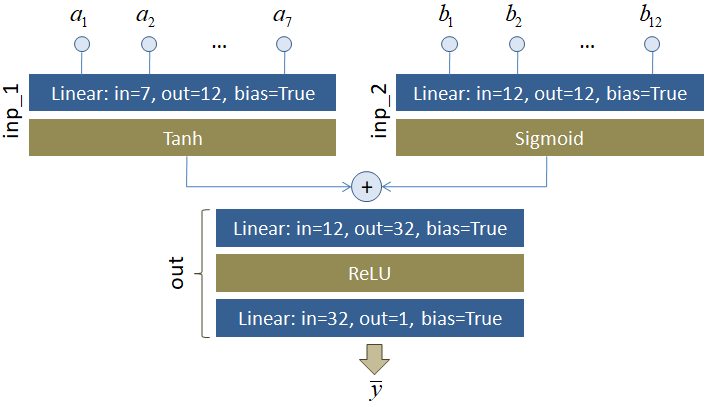

In [1]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели

batch_size=12
a = torch.rand(batch_size, 7) # тензоры a, b в программе не менять
b = torch.rand(batch_size, 12)

# здесь продолжайте программу
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.inp_1 = nn.Sequential(
            nn.Linear(7, 12, bias=True),
            nn.Tanh()
        )
        self.inp_2 = nn.Sequential(
            nn.Linear(12, 12, bias=True),
            nn.Sigmoid()
        )
        self.out = nn.Sequential(
            nn.Linear(12, 32, bias=True),
            nn.ReLU(),
            nn.Linear(32, 1, bias=True)
        )

    def forward(self, a, b):
        ar = self.inp_1(a)
        br = self.inp_2(b)
        ab = ar + br
        return self.out(ab)
    
model = Model()

model.eval()

predict = model(a, b)
predict

tensor([[0.0513],
        [0.0581],
        [0.0297],
        [0.0556],
        [0.0884],
        [0.0439],
        [0.0670],
        [0.0621],
        [0.0278],
        [0.0667],
        [0.1630],
        [0.0144]], grad_fn=<AddmmBackward0>)



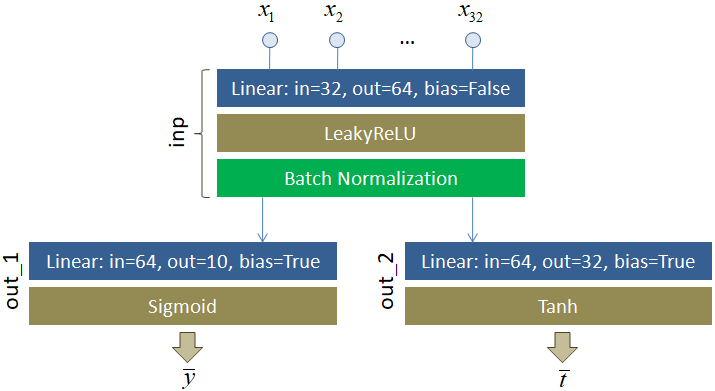

In [3]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.inp = nn.Sequential(
            nn.Linear(32, 64, bias=False),
            nn.LeakyReLU(),
            nn.BatchNorm1d(64)    
        )
        self.out_1 = nn.Sequential(nn.Linear(64, 10, bias=True), nn.Sigmoid())
        self.out_2 = nn.Sequential(nn.Linear(64, 32, bias=True), nn.Tanh())

    def forward(self, x):
        inp = self.inp(x)
        y = self.out_1(inp)
        t = self.out_2(inp)
        return (y, t)

batch_size=28
x = torch.rand(batch_size, 32) # тензор x в программе не менять

# здесь продолжайте программу
model = Model()

model.eval()

predict_y, predict_t = model(x)
predict_y, predict_t

(tensor([[0.5457, 0.5085, 0.4897, 0.4846, 0.5124, 0.4719, 0.4652, 0.4973, 0.5531,
          0.5727],
         [0.5143, 0.4797, 0.4969, 0.4886, 0.5287, 0.4748, 0.4462, 0.4510, 0.5447,
          0.5505],
         [0.5426, 0.5002, 0.4734, 0.4883, 0.4998, 0.4828, 0.4375, 0.4491, 0.5863,
          0.5499],
         [0.5564, 0.5118, 0.5008, 0.5252, 0.4942, 0.4904, 0.4626, 0.4891, 0.5571,
          0.5361],
         [0.5410, 0.5047, 0.5149, 0.4994, 0.5060, 0.4939, 0.4629, 0.4704, 0.5501,
          0.5576],
         [0.5508, 0.5090, 0.5142, 0.5226, 0.4988, 0.4941, 0.4735, 0.4772, 0.5575,
          0.5251],
         [0.5363, 0.5175, 0.5050, 0.5019, 0.4738, 0.4869, 0.4590, 0.4870, 0.5681,
          0.5439],
         [0.5272, 0.4976, 0.4937, 0.4872, 0.5085, 0.4815, 0.4157, 0.4286, 0.5560,
          0.5494],
         [0.5528, 0.5191, 0.5081, 0.5242, 0.4770, 0.4950, 0.4634, 0.4704, 0.5636,
          0.5360],
         [0.5099, 0.5000, 0.4880, 0.4917, 0.4822, 0.4806, 0.4456, 0.4556, 0.5454,
         



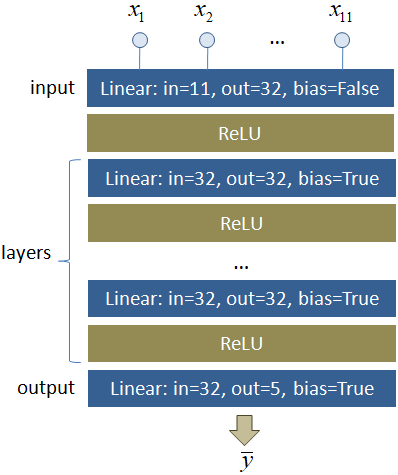

In [7]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели
class DeepNetwork(nn.Module):
    def __init__(self, n):
        super().__init__()

        self.input = nn.Linear(11, 32, bias=False)
        self.layers = nn.ModuleList(
            [nn.Linear(32, 32, bias=True) for _ in range(n)]    
        )
        self.output = nn.Linear(32, 5, bias=True)

    def forward(self, x):
        x = self.input(x).relu()
        for layer in self.layers:
            x = layer(x).relu()
            # x = torch.relu(x)
        x = self.output(x)

        return x


n = int(input()) # это значение в программе не менять

batch_size = 18
x = torch.rand(batch_size, 11) # тензор x в программе не менять

# здесь продолжайте программу
model = DeepNetwork(n)

model.eval()

predict = model(x)
print(predict)

# Проверка
print(predict.shape)
for name, param in model.named_parameters():
    print(f"Имя параметра: {name}")

tensor([[-0.0419,  0.0779,  0.1039,  0.0877,  0.1092],
        [-0.0264,  0.0751,  0.1169,  0.0889,  0.1037],
        [-0.0323,  0.0791,  0.1092,  0.0857,  0.1036],
        [-0.0285,  0.0783,  0.0933,  0.0899,  0.0967],
        [-0.0412,  0.0853,  0.1072,  0.0786,  0.1038],
        [-0.0325,  0.0756,  0.0934,  0.0893,  0.1052],
        [-0.0336,  0.0807,  0.1014,  0.0860,  0.0929],
        [-0.0324,  0.0767,  0.1099,  0.0878,  0.1022],
        [-0.0340,  0.0808,  0.1064,  0.0856,  0.1036],
        [-0.0278,  0.0775,  0.1093,  0.0843,  0.1043],
        [-0.0355,  0.0899,  0.1190,  0.0771,  0.1019],
        [-0.0252,  0.0723,  0.1021,  0.0904,  0.0978],
        [-0.0244,  0.0836,  0.1029,  0.0850,  0.0997],
        [-0.0383,  0.0953,  0.1219,  0.0766,  0.1082],
        [-0.0393,  0.0907,  0.1154,  0.0711,  0.1077],
        [-0.0392,  0.0806,  0.1031,  0.0817,  0.1091],
        [-0.0350,  0.0898,  0.1139,  0.0751,  0.1017],
        [-0.0397,  0.0876,  0.1110,  0.0750,  0.1035]],
       gr

In [11]:
import torch
import torch.nn as nn

# здесь объявляйте класс модели
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.input = nn.Linear(64, 32, bias=True)
        self.blocks = nn.ModuleDict({
            'block_1': nn.Sequential(
                nn.Linear(32, 32, bias=False),
                nn.ELU(),
                nn.BatchNorm1d(32)    
            ),
            'block_2': nn.Sequential(
                nn.Linear(32, 32, bias=True),
                nn.ReLU(),
                nn.Dropout(p=0.4)   
            )
        })
        self.output = nn.Linear(32, 10, bias=True)

    def forward(self, x, type_block='block_1'):
        x = self.input(x).relu()
        x = self.blocks[type_block](x)
        x = self.output(x)
        
        return x

batch_size = 100
x = torch.rand(batch_size, 64) # тензор x в программе не менять

# здесь продолжайте программу
model = Model()

model.eval()

predict = model(x, type_block='block_2')
predict

tensor([[ 0.0313,  0.1284, -0.0064, -0.1723, -0.1614, -0.0905, -0.0508,  0.0577,
         -0.0224,  0.1911],
        [-0.0289,  0.0828,  0.0109, -0.1406, -0.1880, -0.0987, -0.0294, -0.0302,
         -0.1252,  0.0806],
        [ 0.0230,  0.0997,  0.0185, -0.2000, -0.1865, -0.0910, -0.0342,  0.0032,
         -0.0928,  0.1229],
        [ 0.0046,  0.0875,  0.0268, -0.1235, -0.1740, -0.0926, -0.0554,  0.0063,
         -0.0969,  0.1387],
        [ 0.0427,  0.1217,  0.0137, -0.1194, -0.2028, -0.1187, -0.0534,  0.0734,
         -0.0153,  0.1565],
        [ 0.0290,  0.0618,  0.0184, -0.1437, -0.1184, -0.0888, -0.0660,  0.0248,
         -0.1024,  0.1800],
        [ 0.0917,  0.0725,  0.0021, -0.1699, -0.2507, -0.1149, -0.0433,  0.0455,
         -0.0486,  0.1965],
        [ 0.0571,  0.1108,  0.0157, -0.1335, -0.1675, -0.0902, -0.0370,  0.0386,
         -0.0357,  0.1889],
        [ 0.0102,  0.1304,  0.0543, -0.1069, -0.1687, -0.0543, -0.0267, -0.0233,
         -0.1022,  0.0863],
        [-0.0156,  